In [1]:
library(Signac)
library(Seurat)
library(BSgenome.Mmusculus.UCSC.mm10)
library(dplyr)
library(chromVAR)
library(scop)
#####################
set.seed(4180)
setwd("/")
cols <- c("#444576", "#4682B4", "#AEDEEE",
 "#FFD790", "#FFA500", "#C65762",
 "#FBDFDE", "#F6EFCF")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BSgenome

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    u

In [2]:
pal(4)

[1] "#444576" "#C9DBCE" "#D97041" "#F6EFCF"

In [2]:
mHeart <- readRDS("~data/mHeart.Rds")
DefaultAssay(mHeart) <- 'RNA'

In [2]:
seurat_obj <- readRDS("~data/vCM.Rds")

In [3]:
# Get UMAP/TSNE coordinates of each cell using the Embeddings function
write.csv(Embeddings(seurat_obj, reduction = "umap"), file = "cell_embeddings.csv")
# Get the barcode of each cell
write.csv(Cells(seurat_obj), file = "cellID_obs.csv", row.names = FALSE)
# Extract celltype information of each cell
write.csv(seurat_obj@meta.data[, 'subtype', drop = FALSE], file = "cell_celltype.csv")

In [70]:
vCM <- subset(mHeart, celltype %in% "vCM")
vCM[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(vCM)][["ATAC"]]
gc()
DefaultAssay(vCM) <- "RNA"
vCM[["RNA"]] <- CreateAssay5Object(counts = GetAssayData(vCM,
 assay = "RNA",
 layer = "counts"
))
vCM[["RNA"]] <- split(vCM[["RNA"]], f = vCM$orig.ident)
vCM <- vCM %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp")) %>%
 RunPCA()
vCM <- IntegrateLayers(
 object = vCM, method = HarmonyIntegration, assay = "RNA",
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
vCM[["RNA"]] <- JoinLayers(vCM[["RNA"]])

In [52]:
vCM

An object of class Seurat 
218817 features across 37984 samples within 2 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: ATAC
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

In [63]:
vCM <- FindNeighbors(vCM, reduction = "harmony", dims = 1:20)
vCM <- RunUMAP(vCM, reduction = "harmony", dims = 1:20, assay = "RNA")

Computing nearest neighbor graph



Computing SNN

13:17:24 UMAP embedding parameters a = 0.9922 b = 1.112

13:17:24 Read 37984 rows and found 20 numeric columns

13:17:24 Using Annoy for neighbor search, n_neighbors = 30

13:17:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:17:27 Writing NN index file to temp file /tmp/RtmpIYp3Tc/file1e9ff47af2d84

13:17:27 Searching Annoy index using 1 thread, search_k = 3000

13:17:38 Annoy recall = 100%

13:17:39 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

13:17:41 Initializing from normalized Laplacian + noise (using RSpectra)

13:17:41 Commencing optimization for 200 epochs, with 1647544 positive edges

13:17:41 Using rng type: pcg

13:17:58 Optimization finished



In [61]:
DefaultAssay(vCM) <- "RNA"
vCM <- FindClusters(vCM, resolution = 0.3)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 37984
Number of edges: 669733

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8223
Number of communities: 9
Elapsed time: 4 seconds


5 singletons identified. 4 final clusters.



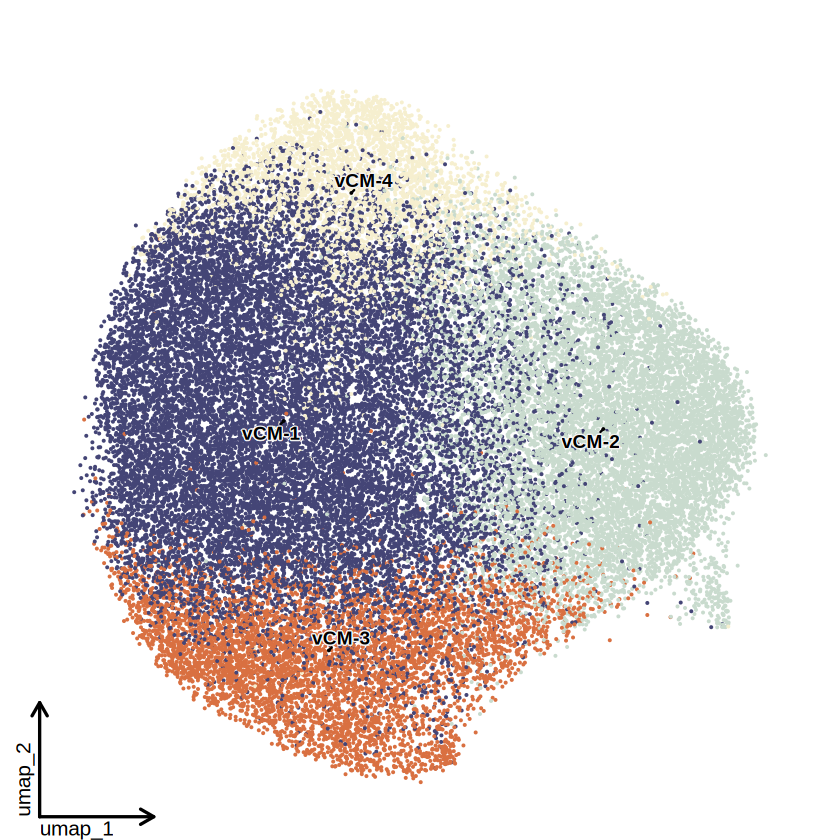

In [64]:
vCM$subtype <- factor(paste("vCM",
 as.numeric(vCM$seurat_clusters),
 sep = "-"
), levels = paste("vCM",
 sort(unique(as.numeric(vCM$seurat_clusters))),
 sep = "-"
))
CellDimPlot(
 srt = vCM, group.by = "subtype", legend.position = "none",
 label_repel = TRUE, label_point_size = 0.01, reduction = "umap",
 label = TRUE, label_insitu = TRUE, theme_use = "theme_blank",
 label.fg = "black", label.bg = "grey95", label.bg.r = 0.1,
 title = "", palcolor = pal(4),
 bg_color = "grey90", raster = FALSE
)


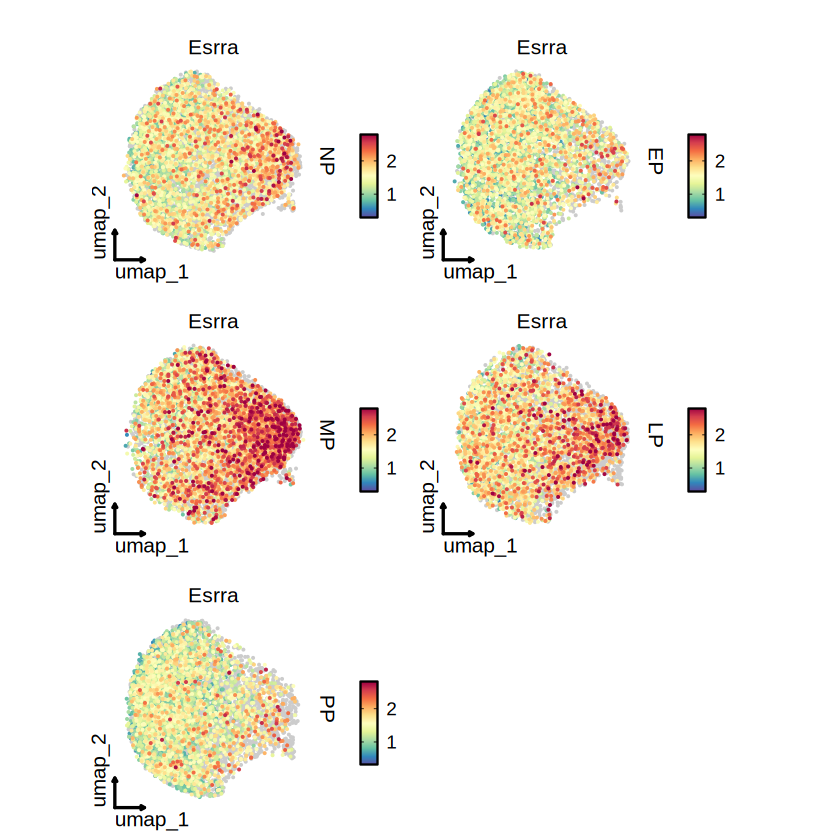

In [65]:
FeatureDimPlot(vCM,features = 'Esrra',split.by = 'group',ncol = 2,theme_use = "theme_blank")

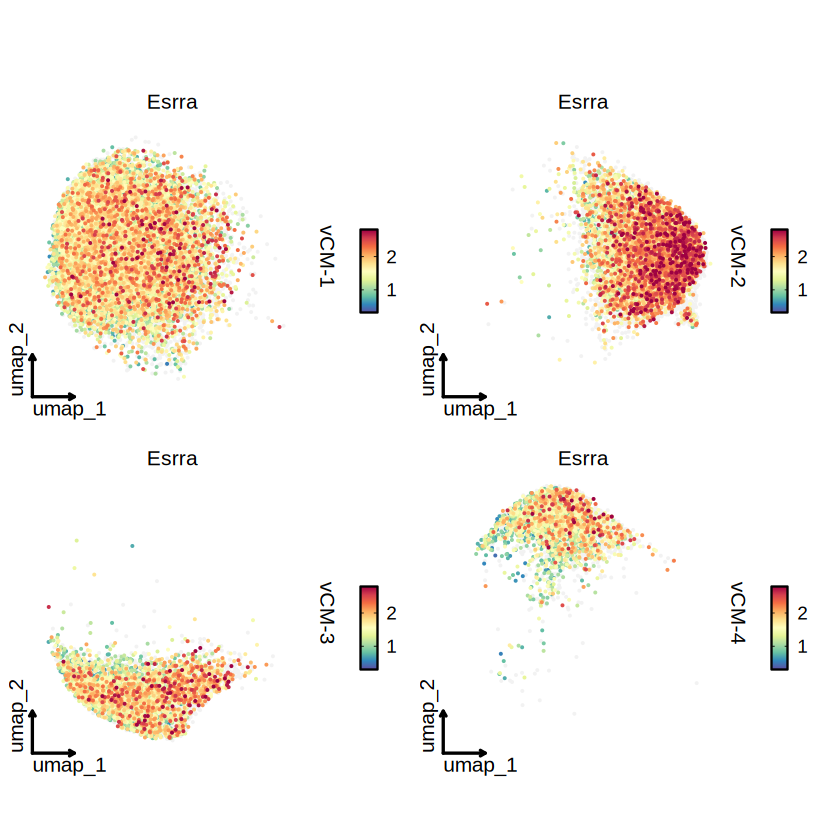

In [66]:
FeatureDimPlot(
 srt = vCM, features = c('Esrra'),legend.position = 'right', assay="RNA",layer='data',split.by = 'subtype',bg_color ='gray95',
 reduction = "umap", theme_use = "theme_blank", raster = FALSE, ncol = 2
)

In [8]:
DefaultAssay(vCM) <- "ATAC"
vCM <- vCM %>%
 FindTopFeatures(min.cutoff = 10 ) %>%
 RunTFIDF() %>%
 RunSVD()
DefaultAssay(vCM) <- "RNA"

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
“Some features contain 0 total counts”
Running SVD

Scaling cell embeddings



In [9]:
saveRDS(vCM, "data/vCM.Rds")

In [1]:
vCM <- readRDS("data/vCM.Rds")

In [2]:
vCM[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(vCM)][["ATAC"]]

Loading required namespace: Signac

Warning message:
“Different cells and/or features from existing assay ATAC”


In [7]:
vCM <- RunDEtest(vCM, group.by = "subtype",fc.threshold = 1,assay = 'RNA',only.pos = T,min.pct = 0.25)
AllMarkers <- filter(vCM@tools$DEtest_subtype$AllMarkers_wilcox, p_val_adj < 0.05,
 test_group_number ==1)
writexl::write_xlsx(AllMarkers,"~/work/YF/mHeart/vCM_allmarkers.xlsx")

ℹ [2026-04-20 09:23:50] Data type is log-normalized

ℹ [2026-04-20 09:23:50] Start differential expression test

ℹ [2026-04-20 09:23:50] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-04-20 09:23:50] Using 1 core

⠙ [2026-04-20 09:23:50] Running for vCM-1 [1/4] ■■          25% | ETA: 28s

⠹ [2026-04-20 09:23:50] Running for vCM-2 [2/4] ■■■■■       50% | ETA: 18s

⠸ [2026-04-20 09:23:50] Running for vCM-3 [3/4] ■■■■■■■     75% | ETA:  9s

✔ [2026-04-20 09:23:50] Completed 4 tasks in 35.9s



ℹ [2026-04-20 09:23:50] Building results

✔ [2026-04-20 09:24:26] Differential expression test completed



Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 7.8 GiB”
`normalized_counts` is not a matrix, converting now.



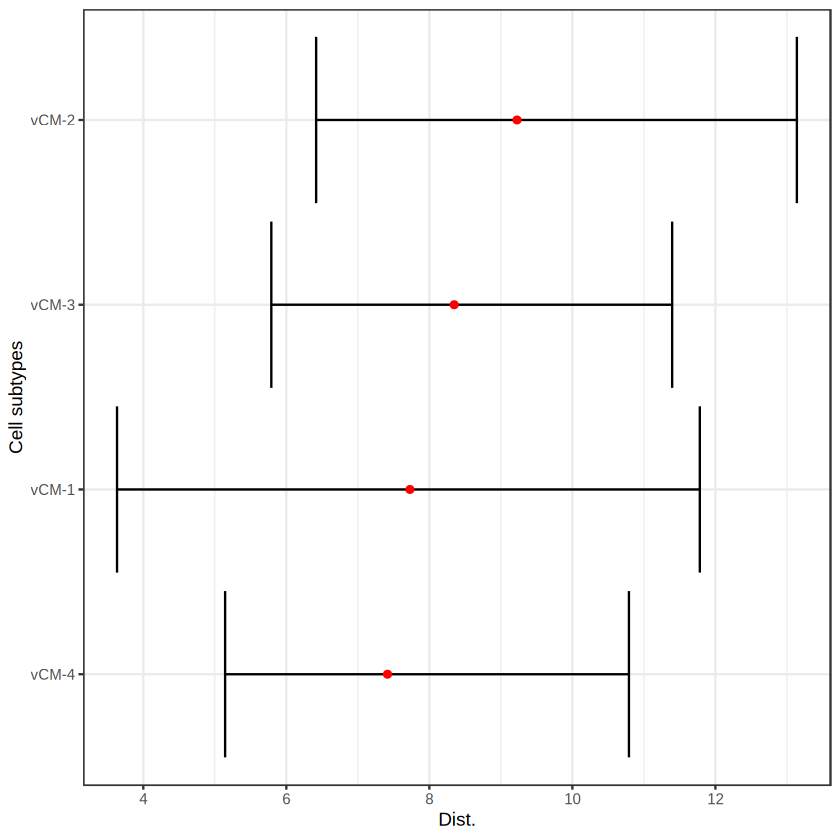

In [27]:
#devtools::install_github("phillipnicol/scDist")
library(dplyr)
library(Seurat)
library(scDist)
library(ggplot2)
library(ggpubr)
######run Dist#################
sim <- list(Y=vCM@assays$RNA$data %>% as.data.frame(),
 meta.data=vCM@meta.data %>% as.data.frame())
out <- scDist(normalized_counts = sim$Y, # scaled data
 meta.data = sim$meta.data, # metadata
 d = 20, # PCA num
 fixed.effects = "group", # stim
 random.effects = c('id'), # batch
 clusters="subtype"
)
p <- DistPlot(out)
p + theme_bw()+xlab(label = 'Cell subtypes')